# Notebook 02 — Centralized Baseline Models


In [1]:
import sys, warnings, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
DATA_CSV = PROCESSED_DIR / 'cicddos2019_processed.csv'
print(f'Data: {DATA_CSV}')

Data: D:\Uni_Project\ML\data\processed\cicddos2019_processed.csv


In [2]:
from src.fl_client.dataset import CONTINUOUS_FEATURES, CATEGORICAL_FEATURES, TARGET_COLUMN

df = pd.read_csv(DATA_CSV, low_memory=False)
print(f'Loaded: {df.shape}')

feature_cols = CONTINUOUS_FEATURES + CATEGORICAL_FEATURES
feature_cols = [c for c in feature_cols if c in df.columns]

X = df[feature_cols].values.astype(np.float32)
y = df[TARGET_COLUMN].values.astype(int)
print(f'X shape: {X.shape}  |  Class balance: {y.mean():.3f} (1=DDoS)')

Loaded: (431371, 14)
X shape: (431371, 13)  |  Class balance: 0.773 (1=DDoS)


In [3]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split
import xgboost as xgb
import pickle

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}  Test: {X_test.shape}')

Train: (345096, 13)  Test: (86275, 13)


---


In [4]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf, target_names=['Benign', 'DDoS']))
rf_f1  = f1_score(y_test, y_pred_rf, average='macro')
rf_auc = roc_auc_score(y_test, y_prob_rf)
print(f'Macro F1: {rf_f1:.4f}  |  AUC-ROC: {rf_auc:.4f}')

=== Random Forest ===
              precision    recall  f1-score   support

      Benign       0.99      1.00      1.00     19566
        DDoS       1.00      1.00      1.00     66709

    accuracy                           1.00     86275
   macro avg       1.00      1.00      1.00     86275
weighted avg       1.00      1.00      1.00     86275

Macro F1: 0.9970  |  AUC-ROC: 0.9996


---


In [5]:
scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

xgb_clf = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)
xgb_clf.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50,
)

y_pred_xgb = xgb_clf.predict(X_test)
y_prob_xgb = xgb_clf.predict_proba(X_test)[:, 1]

print('=== XGBoost ===')
print(classification_report(y_test, y_pred_xgb, target_names=['Benign', 'DDoS']))
xgb_f1  = f1_score(y_test, y_pred_xgb, average='macro')
xgb_auc = roc_auc_score(y_test, y_prob_xgb)
print(f'Macro F1: {xgb_f1:.4f}  |  AUC-ROC: {xgb_auc:.4f}')

assert xgb_f1 >= 0.95, f'XGBoost F1 {xgb_f1:.4f} < 0.95 target!'
print('[M10] ✅ XGBoost >95% F1 achieved.')

[0]	validation_0-logloss:0.60186
[50]	validation_0-logloss:0.01967
[100]	validation_0-logloss:0.01148
[150]	validation_0-logloss:0.00981
[200]	validation_0-logloss:0.00915
[250]	validation_0-logloss:0.00877
[300]	validation_0-logloss:0.00854
[350]	validation_0-logloss:0.00841
[400]	validation_0-logloss:0.00828
[450]	validation_0-logloss:0.00824
[499]	validation_0-logloss:0.00812
=== XGBoost ===
              precision    recall  f1-score   support

      Benign       0.99      1.00      0.99     19566
        DDoS       1.00      1.00      1.00     66709

    accuracy                           1.00     86275
   macro avg       0.99      1.00      1.00     86275
weighted avg       1.00      1.00      1.00     86275

Macro F1: 0.9962  |  AUC-ROC: 0.9999
[M10] ✅ XGBoost >95% F1 achieved.


---


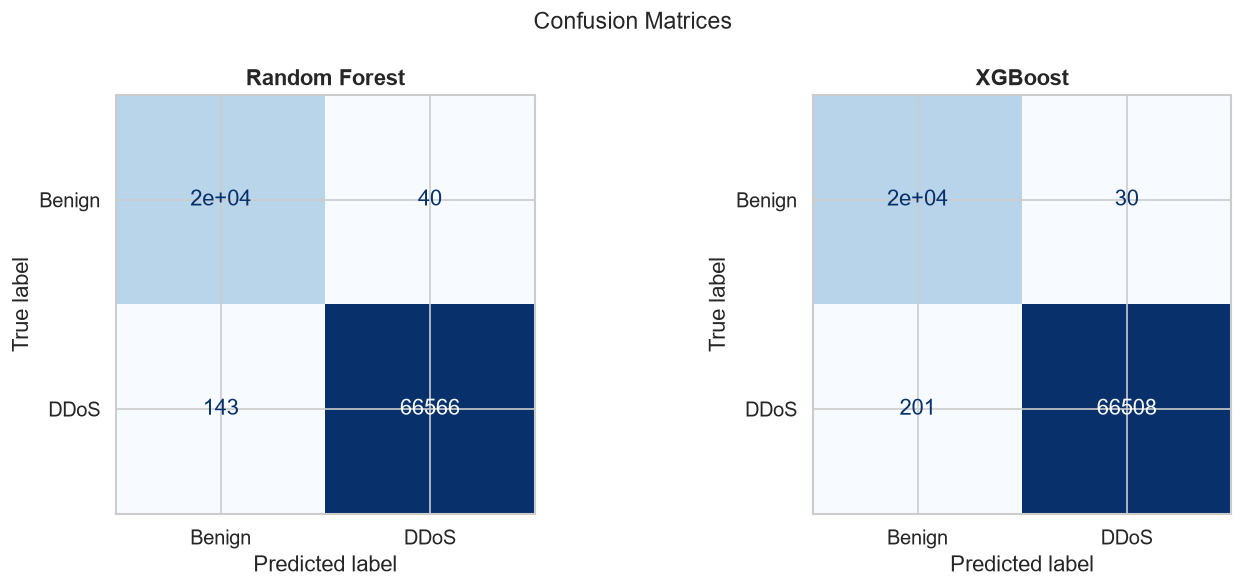

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, y_pred, title in zip(
    axes,
    [y_pred_rf, y_pred_xgb],
    ['Random Forest', 'XGBoost'],
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Benign', 'DDoS'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=13, fontweight='bold')
plt.suptitle('Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'fig_baseline_confusion_matrices.png', bbox_inches='tight')
plt.show()

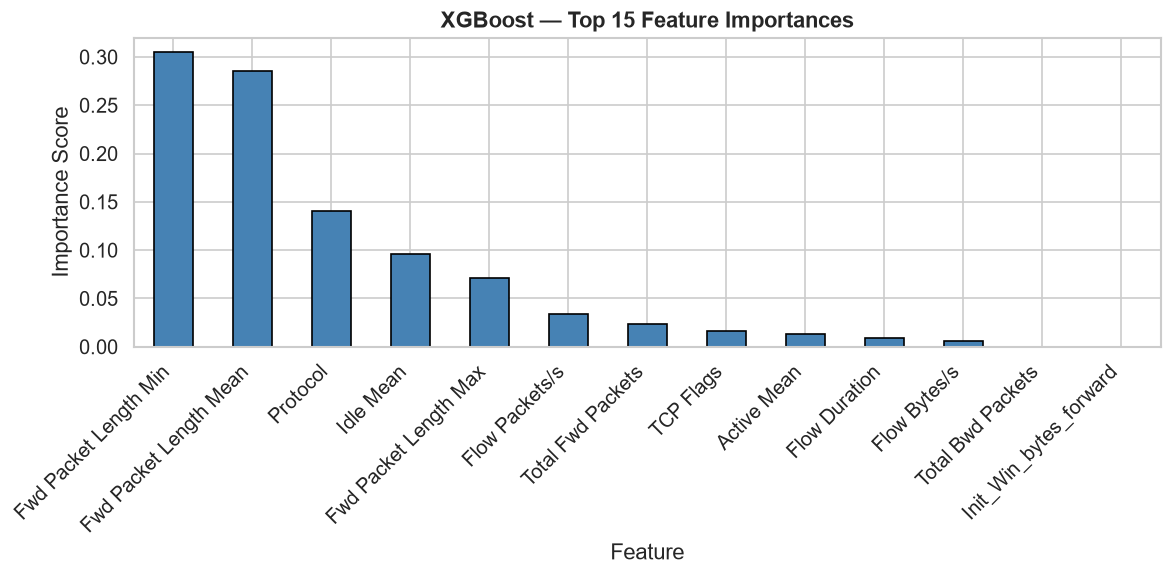

In [7]:
importances = xgb_clf.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
feat_imp.head(15).plot(kind='bar', color='steelblue', edgecolor='black', ax=ax)
ax.set_title('XGBoost — Top 15 Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'fig_xgb_feature_importance.png', bbox_inches='tight')
plt.show()

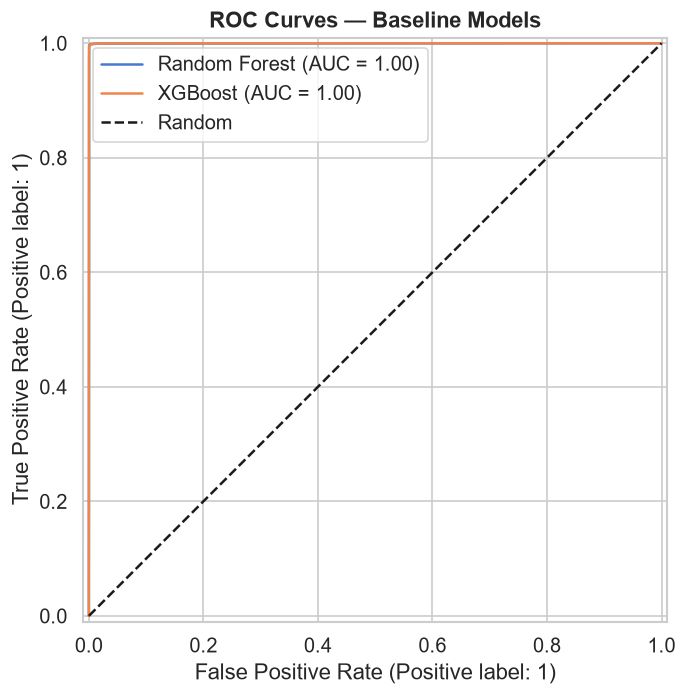

In [8]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))
for name, prob in [('Random Forest', y_prob_rf), ('XGBoost', y_prob_xgb)]:
    RocCurveDisplay.from_predictions(y_test, prob, name=name, ax=ax)
ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_title('ROC Curves — Baseline Models', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'fig_baseline_roc_curves.png', bbox_inches='tight')
plt.show()

In [9]:
with open(PROCESSED_DIR / 'rf_baseline.pkl', 'wb') as f:
    pickle.dump(rf, f)
xgb_clf.save_model(str(PROCESSED_DIR / 'xgb_baseline.json'))

metrics = {
    'random_forest': {'macro_f1': round(rf_f1, 4), 'auc_roc': round(rf_auc, 4)},
    'xgboost':       {'macro_f1': round(xgb_f1, 4), 'auc_roc': round(xgb_auc, 4)},
}
with open(PROCESSED_DIR / 'baseline_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print(json.dumps(metrics, indent=2))
print('[M10] ✅ Baseline models and metrics saved.')

{
  "random_forest": {
    "macro_f1": 0.997,
    "auc_roc": 0.9996
  },
  "xgboost": {
    "macro_f1": 0.9962,
    "auc_roc": 0.9999
  }
}
[M10] ✅ Baseline models and metrics saved.


## Summary
